In [1]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch.optim as optim
import os, shutil
import matplotlib.pyplot as plt
from datetime import datetime
from PIL import Image
import torch.nn.functional as F

In [2]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
%%bash
curl -L -o /content/dogs-vs-cats.zip \
  https://www.kaggle.com/api/v1/datasets/download/biaiscience/dogs-vs-cats

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  816M  100  816M    0     0  15.5M      0  0:00:52  0:00:52 --:--:-- 16.4M


In [4]:
!unzip -q dogs-vs-cats.zip -d dogs-vs-cats

In [5]:
os.makedirs('dogs-vs-cats/train/train/cats', exist_ok=True)
os.makedirs('dogs-vs-cats/train/train/dogs', exist_ok=True)

In [6]:
for filename in os.listdir('dogs-vs-cats/train/train'):
    if filename.startswith('cat.'):
        shutil.move(f'dogs-vs-cats/train/train/{filename}', f'dogs-vs-cats/train/train/cats/{filename}')
    elif filename.startswith('dog.'):
        shutil.move(f'dogs-vs-cats/train/train/{filename}', f'dogs-vs-cats/train/train/dogs/{filename}')

In [7]:
data_dir = 'dogs-vs-cats'

train_transforms = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(data_dir + '/train/train', transform=train_transforms)

train_size = int(0.70 * len(train_data))
val_size   = int(0.15 * len(train_data))
test_size  = len(train_data) - train_size - val_size

train_subset, val_subset, test_subset = random_split(
    train_data, [train_size, val_size, test_size]
)

print(f"Train: {train_size} | Val: {val_size} | Test: {test_size}")

trainloader = DataLoader(train_subset, batch_size=64, shuffle=True,  num_workers=2)
valloader   = DataLoader(val_subset,   batch_size=64, shuffle=False, num_workers=2)
testloader  = DataLoader(test_subset,  batch_size=64, shuffle=False, num_workers=2)

Train: 17500 | Val: 3750 | Test: 3750


In [8]:
class AlexNet(nn.Module):
    def __init__(self, num_classes):
        super(AlexNet, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=0),
            nn.BatchNorm2d(96),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 3, stride = 2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(96, 256, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 3, stride = 2))
        self.layer3 = nn.Sequential(
            nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU())
        self.layer4 = nn.Sequential(
            nn.Conv2d(384, 384, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU())
        self.layer5 = nn.Sequential(
            nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 3, stride = 2))
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(6400, 4096),
            nn.ReLU())
        self.fc1 = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU())
        self.fc2= nn.Sequential(
            nn.Linear(4096, num_classes))

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.layer5(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc(out)
        out = self.fc1(out)
        out = self.fc2(out)
        return out


In [9]:
num_classes = 2

model = AlexNet(num_classes).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=0.0005)

In [10]:
epochs = 30

history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': []
}

for epoch in range(epochs):
    model.train()
    train_loss = 0
    train_correct = 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += (outputs.argmax(1) == labels).sum().item()

    model.eval()
    val_loss = 0
    val_correct = 0

    with torch.no_grad():
        for images, labels in valloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            val_correct += (outputs.argmax(1) == labels).sum().item()

    history['train_loss'].append(train_loss / len(trainloader))
    history['val_loss'].append(val_loss / len(valloader))
    history['train_acc'].append(train_correct / len(train_subset))
    history['val_acc'].append(val_correct / len(val_subset))

    print(f"Epoch {epoch+1}/{epochs} | "
      f"Train Loss: {history['train_loss'][-1]:.3f} | "
      f"Val Loss: {history['val_loss'][-1]:.3f} | "
      f"Train Acc: {history['train_acc'][-1]:.3f} | "
      f"Val Acc: {history['val_acc'][-1]:.3f}", flush=True)

# Save the model after training with unique name
final_val_acc = history['val_acc'][-1]

timestamp  = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = os.path.join("models", f"alexnet_cats-vs-dogs_{timestamp}_ep{epochs}")
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, "model.pth")
torch.save(model.state_dict(), model_path)

torch.save(model.state_dict(), model_path)
print(f"\nModel saved as: {model_path}")

Epoch 1/30 | Train Loss: 0.686 | Val Loss: 0.707 | Train Acc: 0.581 | Val Acc: 0.551
Epoch 2/30 | Train Loss: 0.627 | Val Loss: 0.612 | Train Acc: 0.650 | Val Acc: 0.663
Epoch 3/30 | Train Loss: 0.591 | Val Loss: 0.582 | Train Acc: 0.682 | Val Acc: 0.695
Epoch 4/30 | Train Loss: 0.549 | Val Loss: 0.528 | Train Acc: 0.720 | Val Acc: 0.743
Epoch 5/30 | Train Loss: 0.519 | Val Loss: 0.515 | Train Acc: 0.741 | Val Acc: 0.734
Epoch 6/30 | Train Loss: 0.494 | Val Loss: 0.499 | Train Acc: 0.755 | Val Acc: 0.752
Epoch 7/30 | Train Loss: 0.476 | Val Loss: 0.492 | Train Acc: 0.768 | Val Acc: 0.746
Epoch 8/30 | Train Loss: 0.451 | Val Loss: 0.502 | Train Acc: 0.781 | Val Acc: 0.746
Epoch 9/30 | Train Loss: 0.430 | Val Loss: 0.461 | Train Acc: 0.792 | Val Acc: 0.784
Epoch 10/30 | Train Loss: 0.417 | Val Loss: 0.395 | Train Acc: 0.802 | Val Acc: 0.817
Epoch 11/30 | Train Loss: 0.398 | Val Loss: 0.425 | Train Acc: 0.813 | Val Acc: 0.809
Epoch 12/30 | Train Loss: 0.389 | Val Loss: 0.380 | Train Acc: 

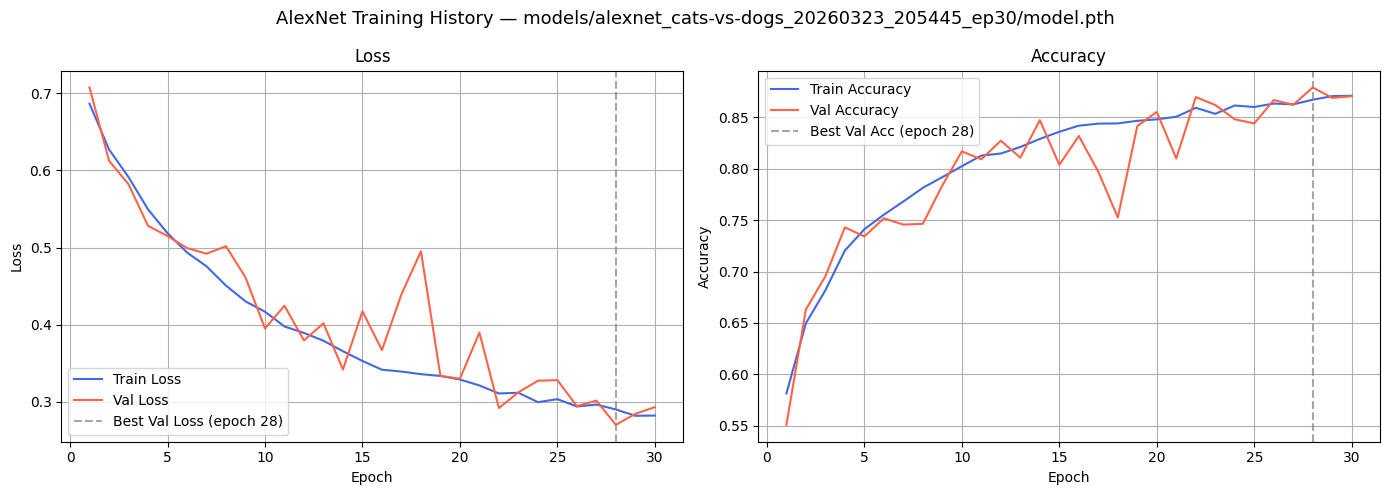

Best Val Loss:     0.270 at epoch 28
Best Val Accuracy: 0.879 at epoch 28
Saved model:       models/alexnet_cats-vs-dogs_20260323_205445_ep30/model.pth


In [12]:
epochs_range = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history['train_loss'], label='Train Loss', color='royalblue')
ax1.plot(epochs_range, history['val_loss'],   label='Val Loss',   color='tomato')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

best_val_loss_epoch = history['val_loss'].index(min(history['val_loss'])) + 1
ax1.axvline(x=best_val_loss_epoch, color='gray', linestyle='--', alpha=0.7,
            label=f'Best Val Loss (epoch {best_val_loss_epoch})')
ax1.legend()

ax2.plot(epochs_range, history['train_acc'], label='Train Accuracy', color='royalblue')
ax2.plot(epochs_range, history['val_acc'],   label='Val Accuracy',   color='tomato')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

best_val_acc_epoch = history['val_acc'].index(max(history['val_acc'])) + 1
ax2.axvline(x=best_val_acc_epoch, color='gray', linestyle='--', alpha=0.7,
            label=f'Best Val Acc (epoch {best_val_acc_epoch})')
ax2.legend()

plt.suptitle(f'AlexNet Training History — {model_path}', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Best Val Loss:     {min(history['val_loss']):.3f} at epoch {best_val_loss_epoch}")
print(f"Best Val Accuracy: {max(history['val_acc']):.3f} at epoch {best_val_acc_epoch}")
print(f"Saved model:       {model_path}")

In [14]:
# Loading the saved model
loaded_model = AlexNet(num_classes).to(device)

model_name = 'models/alexnet_cats-vs-dogs_20260323_205445_ep30/model.pth'

loaded_model.load_state_dict(torch.load(model_name))

loaded_model.eval()

AlexNet(
  (layer1): Sequential(
    (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4))
    (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Sequential(
    (0): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer4): Sequential(
    (0): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  

In [15]:
def predict_image(image_path, model, device):
  class_names = ['Cat', 'Dog']

  transform = transforms.Compose([
      transforms.Resize(255),
      transforms.CenterCrop(224),
      transforms.ToTensor(),
      transforms.Normalize([0.485, 0.456, 0.406],
                            [0.229, 0.224, 0.225])
  ])

  image = Image.open(image_path).convert('RGB')
  input_tensor = transform(image).unsqueeze(0).to(device)

  model.to(device)
  with torch.no_grad():
      output = model(input_tensor)
      probabilities = F.softmax(output, dim=1)[0]

  predicted_class = class_names[probabilities.argmax().item()]
  confidence      = probabilities.max().item() * 100

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

  ax1.imshow(image)
  ax1.axis('off')
  ax1.set_title(f'Prediction: {predicted_class} ({confidence:.1f}%)',
                fontsize=14, fontweight='bold',
                color='green' if confidence > 80 else 'orange')

  colors = ['#FF6B6B', '#4ECDC4']
  bars = ax2.bar(class_names,
                  [p.item() * 100 for p in probabilities],
                  color=colors, edgecolor='black', width=0.4)

  for bar, prob in zip(bars, probabilities):
      ax2.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1,
                f'{prob.item() * 100:.1f}%',
                ha='center', fontsize=12, fontweight='bold')

  ax2.set_ylim(0, 110)
  ax2.set_ylabel('Confidence (%)')
  ax2.set_title('Class Probabilities')
  ax2.grid(axis='y', linestyle='--', alpha=0.7)

  plt.suptitle('AlexNet — Dogs vs Cats', fontsize=13)
  plt.tight_layout()
  plt.show()

  return predicted_class, confidence



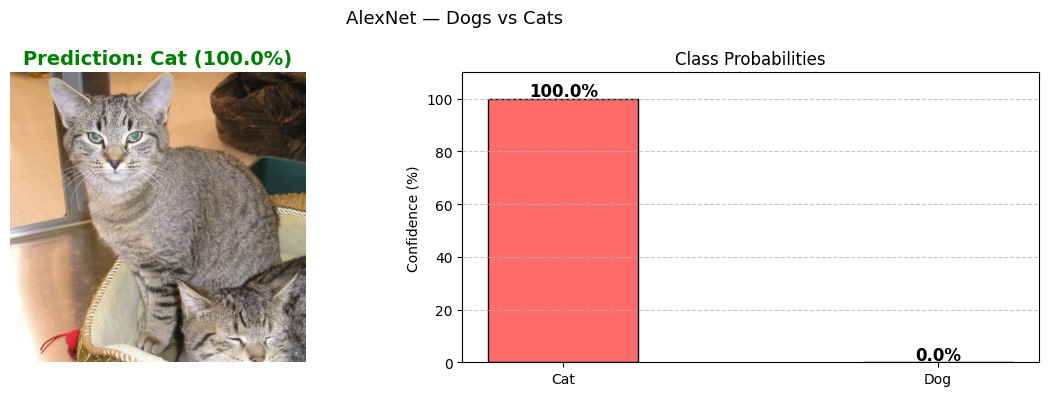

('Cat', 99.98939037322998)

In [16]:
image_path = 'dogs-vs-cats/test/test/10040.jpg'

predict_image(image_path, model, device)


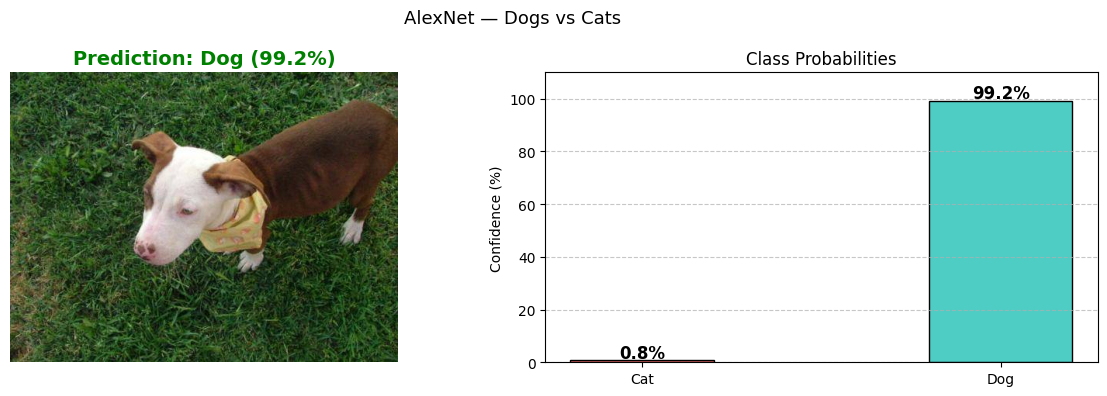

('Dog', 99.20146465301514)

In [22]:
image_path = 'dogs-vs-cats/test/test/10010.jpg'

predict_image(image_path, model, device)